# Electrostatic energy from atomic multipoles

This notebook loads periodic bulk structures and non-periodic clusters, builds
inputs for the electrostatic energy block, and evaluates the energy for random
multipoles.


In [6]:
import torch
from pathlib import Path
from scipy.constants import pi
from ase.io import read

from graph_longrange.kspace import compute_k_vectors_flat
from graph_longrange.energy import GTOElectrostaticEnergy
from graph_longrange.gto_utils import gto_basis_kspace_cutoff

torch.set_default_dtype(torch.float64)


In [7]:
example_dir = Path.cwd()
if not (example_dir / "bulk.xyz").exists():
    example_dir = Path("graph_longrange_refactor/examples")

bulk_structures = read(example_dir / "bulk.xyz", ":")
cluster_structures = read(example_dir / "clusters.xyz", ":")

print(f"Loaded {len(bulk_structures)} bulk configs")
print(f"Loaded {len(cluster_structures)} cluster configs")


Loaded 4 bulk configs
Loaded 4 cluster configs


This repo doesn't convert atoms into batched tensors, so we'll do this manually:

In [8]:
def atoms_list_to_batch(atoms_list):
    positions = []
    batch = []
    cells = []
    volumes = []
    pbcs = []

    for graph_i, atoms in enumerate(atoms_list):
        pos = torch.tensor(atoms.get_positions(), dtype=torch.get_default_dtype())
        positions.append(pos)
        batch.append(torch.full((pos.shape[0],), graph_i, dtype=torch.long))

        cell = torch.tensor(atoms.cell.array, dtype=torch.get_default_dtype())
        if torch.allclose(cell, torch.zeros_like(cell)):
            cell = torch.eye(3, dtype=cell.dtype)
        cells.append(cell)
        volumes.append(abs(torch.det(cell)))
        pbcs.append(torch.tensor(atoms.pbc, dtype=torch.bool))

    return (
        torch.cat(positions, dim=0),
        torch.cat(batch, dim=0),
        torch.stack(cells, dim=0),
        torch.stack(volumes, dim=0),
        torch.stack(pbcs, dim=0),
    )

In [9]:
# density_max_l is the multipole order. 0=charges, 1=charges+dipoles, etc...
# the realspace evalation is currently supported for only l<=1. 
density_max_l = 1

# this is sigma_n in the GTO basis, we generally use quite wide gaussians in ML models
density_smearing_width = 1.5

# use this function for a heuristic estimate of the k-space cutoff, 
# which is needed to determine the number of k-vectors to use in the reciprocal space sum.
kspace_cutoff = gto_basis_kspace_cutoff(
    sigmas=[density_smearing_width],
    max_l=density_max_l,
)

energy_block = GTOElectrostaticEnergy(
    density_max_l=density_max_l,
    density_smearing_width=density_smearing_width,
    kspace_cutoff=kspace_cutoff,
    include_self_interaction=True,
    pbc_handling="mixed_periodic",
)

## Periodic bulk example

One needs to create a set of k-vectors based on the unit cell. For this, use `compute_k_vectors_flat`.

This function provides only a half sphere of k-vectors with $k_x>0$. This is because the functions are all real, so we only need to store half of the fourier series coefficients. 

as well as the `k_vectors`, the function returns
- `k_norm2`, squared norm of k_vectors
- `k_vector_batch`, a tensor like the `batch` describing which batch each k-vector belongs in
- `k0_mask` marks there the $\mathbf{k}=\mathbf{0}$ entries are. 


In [ ]:
positions, batch, cell, volume, pbc = atoms_list_to_batch(bulk_structures)

r_cell = 2 * pi * torch.linalg.inv(cell).transpose(-1, -2)
k_vectors, k_norm2, k_vector_batch, k0_mask = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell,
    r_cell_vectors=r_cell,
)

# random multipoles which sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l+1)**2)
multipoles[:,0] -= multipoles[:,0].mean()

energy_bulk = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

energy_bulk


tensor([33.7462, 23.1285, 14.6436, 17.5880])

## Non-periodic cluster example

In [11]:
positions, batch, cell, volume, pbc = atoms_list_to_batch(cluster_structures)

energy_block_realspace = GTOElectrostaticEnergy(
    density_max_l=density_max_l,
    density_smearing_width=density_smearing_width,
    kspace_cutoff=kspace_cutoff,
    include_self_interaction=True,
    pbc_handling="realspace",
)

# charges don't have to sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l+1)**2)

# placeholders, ignored in real-space path
k_vectors = torch.zeros((1, 3), dtype=positions.dtype)
k_norm2 = torch.zeros((1,), dtype=positions.dtype)
k_vector_batch = torch.zeros((1,), dtype=torch.long)
k0_mask = torch.ones((1,), dtype=positions.dtype)

energy_cluster = energy_block_realspace(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

energy_cluster


tensor([3.1523, 3.6764, 0.5649, 3.5951])

## Dipole Correction for Slabs (z axis only)

In "mixed_periodic" mode, setting `pbc=TTF` enables the dipole correction.

> 
> NOTE:
>
> slabs in this repo must have the nonperiodic direction equal to the third cell vector (~ z diection)
>

Below we show the energy change when one sets `pbc=TTF` instead of `pbc=TTT`

In [12]:
# make a slab
slab_atoms = bulk_structures[0].copy()
cell = slab_atoms.get_cell()
cell[2,2] = 60.0
slab_atoms.set_cell(cell)

# get k vectors for this cell shape
positions, batch, cell, volume, pbc = atoms_list_to_batch([slab_atoms])
r_cell = 2 * pi * torch.linalg.inv(cell).transpose(-1, -2)
k_vectors, k_norm2, k_vector_batch, k0_mask = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell,
    r_cell_vectors=r_cell,
)

# set some multipoles which sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l+1)**2)
multipoles[:,0] -= multipoles[:,0].mean()

# set pbc to TTT and get energy:
slab_atoms.set_pbc([True, True, True])
positions, batch, cell, volume, pbc = atoms_list_to_batch([slab_atoms])

# mixed periodic mode automatically applies slab and molecule corrections depending on pbc
energy_periodic = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

# set pbc to TTF and get energy:
slab_atoms.set_pbc([True, True, False])
positions, batch, cell, volume, pbc = atoms_list_to_batch([slab_atoms])

energy_slab = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)
 
energy_periodic, energy_slab

(tensor([48.5684]), tensor([48.6094]))

The difference can be very large, because here we are using random multipoles and hence the dipole may be large.

## Convergence rate of energy with and without the dipole correction

The cell below computes the energy for the same config above as a function of z direction cell length, with and without the dipole correction.


get a sense for the number of k-vectors:
 box length (Ang) 	| number of k-vectors 
---------------------------------------------
	30.0 		| 	293  
	43.4 		| 	421  
	62.9 		| 	623  
	91.0 		| 	899  
	131.8 		| 	1299  
	190.8 		| 	1873  
	276.3 		| 	2710  
	400.0 		| 	3922  


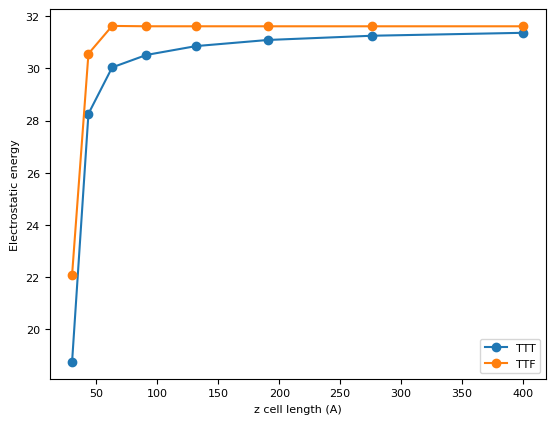

In [21]:
# batch evaluation across varying z lengths
import numpy as np
import matplotlib.pyplot as plt

lengths = np.geomspace(30.0, 400.0, 8)
slabs_ttt = []
slabs_ttf = []

for length in lengths:
    atoms = bulk_structures[0].copy()
    cell = atoms.get_cell()
    cell[2, 2] = float(length)
    atoms.set_cell(cell)

    atoms_ttt = atoms.copy()
    atoms_ttt.set_pbc([True, True, True])
    slabs_ttt.append(atoms_ttt)

    atoms_ttf = atoms.copy()
    atoms_ttf.set_pbc([True, True, False])
    slabs_ttf.append(atoms_ttf)

# TTT batch
positions_ttt, batch_ttt, cell_ttt, volume_ttt, pbc_ttt = atoms_list_to_batch(slabs_ttt)
r_cell_ttt = 2 * pi * torch.linalg.inv(cell_ttt).transpose(-1, -2)
k_vectors_ttt, k_norm2_ttt, k_vector_batch_ttt, k0_mask_ttt = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell_ttt,
    r_cell_vectors=r_cell_ttt,
)
multipoles = 0.25 * torch.randn(192, (density_max_l + 1) ** 2)
multipoles[:, 0] -= multipoles[:, 0].mean()
multipoles = multipoles.repeat(lengths.shape[0], 1)

energies_ttt = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_ttt,
    batch=batch_ttt,
    volume=volume_ttt,
    pbc=pbc_ttt,
)

# TTF batch
positions_ttf, batch_ttf, cell_ttf, volume_ttf, pbc_ttf = atoms_list_to_batch(slabs_ttf)
energies_ttf = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_ttf,
    batch=batch_ttf,
    volume=volume_ttf,
    pbc=pbc_ttf,
)

plt.figure()
plt.plot(lengths, energies_ttt.detach().cpu().numpy(), "-o", label="TTT")
plt.plot(lengths, energies_ttf.detach().cpu().numpy(), "-o", label="TTF")
plt.xlabel("z cell length (A)")
plt.ylabel("Electrostatic energy")
plt.legend()

print('\nget a sense for the number of k-vectors:')
num_k_vectors_per_graph = torch.bincount(k_vector_batch_ttt)
print(' box length (Ang) \t| number of k-vectors ')
print('---------------------------------------------')
for length, num_k in zip(lengths, num_k_vectors_per_graph):
    print(f'\t{length:.1f} \t\t| \t{num_k}  ')

## Periodic evaluation for a cluster in a box

There are two ways to do a calculation of a molecule in a mox. One is the realspace code, and the other is to do a periodic calculation and then add monopole correction terms. If you are training on batches with mixed periodicity, it is often more efficient to do the latter, instead of splitting the batch up and passing different configurations through different functions.

The two methods will give slightly different answers, but will agree when a large box and k-space cutoff is used. The cell below shows the difference.

In [30]:
cluster = cluster_structures[0].copy()
cluster.set_cell([30.0, 30.0, 30.0])
cluster.set_pbc([False, False, False])

positions, batch, cell, volume, pbc = atoms_list_to_batch([cluster])
r_cell = 2 * pi * torch.linalg.inv(cell).transpose(-1, -2)
k_vectors, k_norm2, k_vector_batch, k0_mask = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell,
    r_cell_vectors=r_cell,
)

# multipoles which don't sum to 0
multipoles = 0.25 * torch.randn(positions.shape[0], (density_max_l + 1) ** 2)
print('total charge:', multipoles[:, 0].sum().item())

# realspace evaluation
energy_realspace_evaluator = energy_block_realspace(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

# pbc evaluation with FFF, which adds monopole/dipole corrections in mized_periodic mode.
# you'll get the same answer by setting pbc_handling="molecule_in_box"
energy_periodic_evaluator = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

# also compute the energy with TTT to show the size of the error
cluster.set_pbc([True, True, True])
positions, batch, cell, volume, pbc = atoms_list_to_batch([cluster])
energy_TTT = energy_block(
    k_vectors=k_vectors,
    k_norm2=k_norm2,
    k_vector_batch=k_vector_batch,
    k0_mask=k0_mask,
    source_feats=multipoles,
    node_positions=positions,
    batch=batch,
    volume=volume,
    pbc=pbc,
)

print("Energy real-space:\t\t {:.3f} eV".format(energy_realspace_evaluator.item()))
print("Energy periodic + corrections:\t {:.3f} eV".format(energy_periodic_evaluator.item()))
print("Energy periodic:\t\t {:.3f} eV".format(energy_TTT.item()))

total charge: -1.7786053879487236
Energy real-space:		 7.579 eV
Energy periodic + corrections:	 7.602 eV
Energy periodic:		 5.457 eV


## Convergence of the energy of clusters, when using the periodic evaluator

total charge: -1.4000806601906468

doing clusters in huge boxes rapidly gets expensive:
 box length (Ang) 	| number of k-vectors 
---------------------------------------------
	15.0 		| 	183  
	19.7 		| 	400  
	25.8 		| 	920  
	33.8 		| 	2034  
	44.4 		| 	4586  
	58.2 		| 	10432  
	76.3 		| 	23629  
	100.0 		| 	53072  


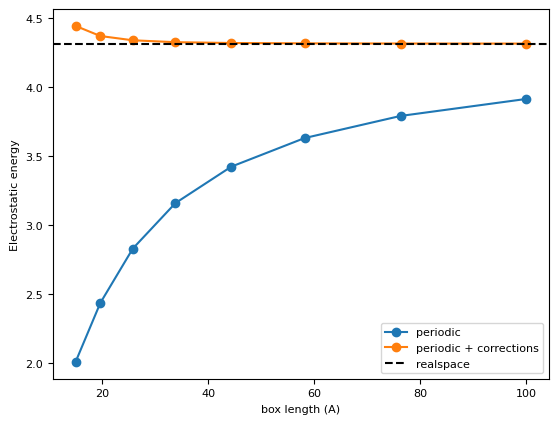

In [32]:
# convergence with cell size for a cluster in a box
import numpy as np
import matplotlib.pyplot as plt

lengths = np.geomspace(15.0, 100.0, 8)

cluster_base = cluster_structures[0].copy()
cluster_base.set_pbc([False, False, False])

base_positions, _, _, _, _ = atoms_list_to_batch([cluster_base])
multipoles_base = 0.25 * torch.randn(base_positions.shape[0], (density_max_l + 1) ** 2)
print('total charge:', multipoles_base[:, 0].sum().item())

# realspace energy (computed once)
cluster_real = cluster_base.copy()
cluster_real.set_cell([30.0, 30.0, 30.0])
positions_rs, batch_rs, cell_rs, volume_rs, pbc_rs = atoms_list_to_batch([cluster_real])
r_cell_rs = 2 * pi * torch.linalg.inv(cell_rs).transpose(-1, -2)
k_vectors_rs, k_norm2_rs, k_vector_batch_rs, k0_mask_rs = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell_rs,
    r_cell_vectors=r_cell_rs,
)
energy_realspace = energy_block_realspace(
    k_vectors=k_vectors_rs,
    k_norm2=k_norm2_rs,
    k_vector_batch=k_vector_batch_rs,
    k0_mask=k0_mask_rs,
    source_feats=multipoles_base,
    node_positions=positions_rs,
    batch=batch_rs,
    volume=volume_rs,
    pbc=pbc_rs,
)

clusters_ttt = []
clusters_fff = []
for length in lengths:
    atoms = cluster_base.copy()
    atoms.set_cell([float(length), float(length), float(length)])

    atoms_ttt = atoms.copy()
    atoms_ttt.set_pbc([True, True, True])
    clusters_ttt.append(atoms_ttt)

    atoms_fff = atoms.copy()
    atoms_fff.set_pbc([False, False, False])
    clusters_fff.append(atoms_fff)

# TTT batch
positions_ttt, batch_ttt, cell_ttt, volume_ttt, pbc_ttt = atoms_list_to_batch(clusters_ttt)
r_cell_ttt = 2 * pi * torch.linalg.inv(cell_ttt).transpose(-1, -2)
k_vectors_ttt, k_norm2_ttt, k_vector_batch_ttt, k0_mask_ttt = compute_k_vectors_flat(
    cutoff=kspace_cutoff,
    cell_vectors=cell_ttt,
    r_cell_vectors=r_cell_ttt,
)
multipoles = multipoles_base.repeat(len(lengths), 1)

energies_ttt = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_ttt,
    batch=batch_ttt,
    volume=volume_ttt,
    pbc=pbc_ttt,
)

positions_fff, batch_fff, cell_fff, volume_fff, pbc_fff = atoms_list_to_batch(clusters_fff)
energies_fff = energy_block(
    k_vectors=k_vectors_ttt,
    k_norm2=k_norm2_ttt,
    k_vector_batch=k_vector_batch_ttt,
    k0_mask=k0_mask_ttt,
    source_feats=multipoles,
    node_positions=positions_fff,
    batch=batch_fff,
    volume=volume_fff,
    pbc=pbc_fff,
)

plt.figure()
plt.plot(lengths, energies_ttt.detach().cpu().numpy(), "-o", label="periodic")
plt.plot(lengths, energies_fff.detach().cpu().numpy(), "-o", label="periodic + corrections")
plt.axhline(energy_realspace.item(), linestyle="--", color="k", label="realspace")
plt.xlabel("box length (A)")
plt.ylabel("Electrostatic energy")
plt.legend()

print('\ndoing clusters in huge boxes rapidly gets expensive:')
num_k_vectors_per_graph = torch.bincount(k_vector_batch_ttt)
print(' box length (Ang) \t| number of k-vectors ')
print('---------------------------------------------')
for length, num_k in zip(lengths, num_k_vectors_per_graph):
    print(f'\t{length:.1f} \t\t| \t{num_k}  ')